## Quantum Gate Simulation with DRAG Pulses

### Hamiltonian Implementation

The system Hamiltonian is based on the transmon qubit model with DRAG pulse shaping [Motzoi et al., PRL 103, 110501 (2009)]:

$
H(t)/\hbar = \Delta|2\rangle\langle 2| + \frac{\epsilon_x(t)}{2}(a + a^\dagger) + \frac{\epsilon_y(t)}{2}i(a^\dagger - a)
$

Where:
- $\Delta = \omega_{12} - \omega_{01}$ is the anharmonicity (-400 MHz in our simulation)
- $\epsilon_x(t)$ is the X-control field (Gaussian envelope)
- $\epsilon_y(t)$ is the Y-control field (DRAG correction)
- $a$/$a^\dagger$ are annihilation/creation operators

### Pulse Parameters
- **Pulse duration**: 6 ns (σ = 1.5 ns)

### Decoherence Model
Included collapse operators for:
- Energy relaxation (T₁ = 20 μs)
- Pure dephasing (T₂ = 10 μs)

HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)
Based on PRL 103, 110501, Eq. (3), with resonant drive (δ₁=0)
H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)
  - Δ/2π = -0.4 GHz (Anharmonicity)
  - (a+a†) is the physical X-drive, which includes λ=√2 implicitly.
  - (σy₀₁) is the effective Y-drive for the DRAG correction.


--- Running Simulation for: Gaussian Pulse ---
  Gate Time: 6.0 ns
  Final Population Percentages:
    P(|0>): 2.6983%
    P(|1>): 97.2224%
    P(|2>): 0.0793%  <-- Leakage


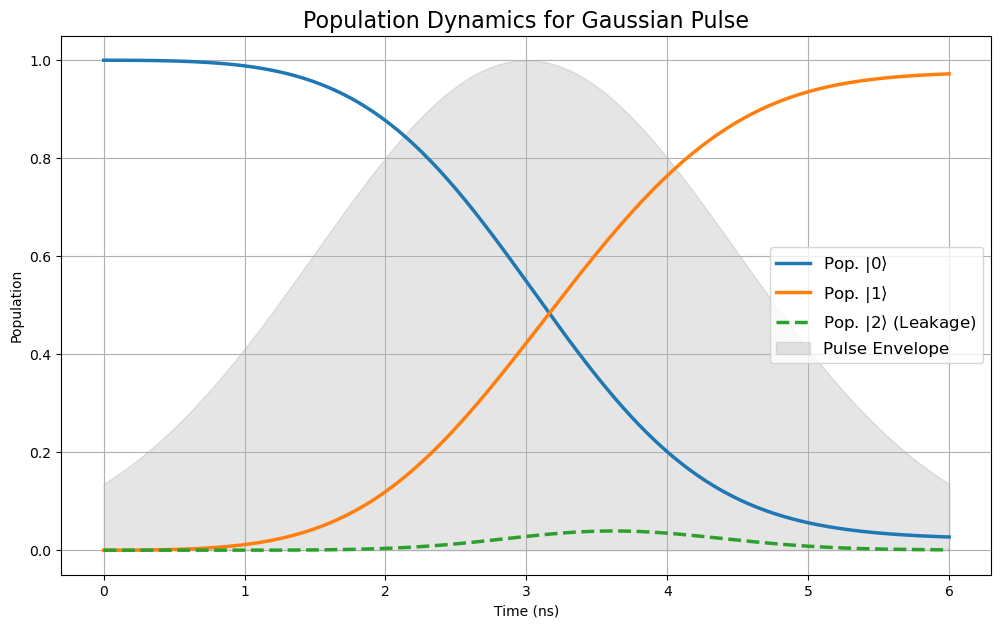

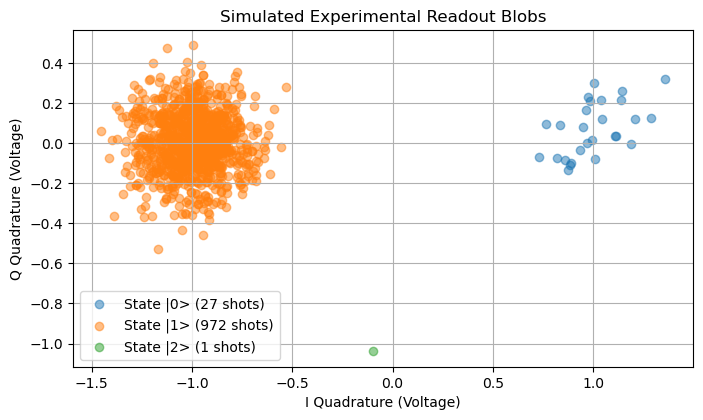


--- Running Simulation for: DRAG Pulse ---
  Gate Time: 6.0 ns
  Final Population Percentages:
    P(|0>): 1.6340%
    P(|1>): 98.2894%
    P(|2>): 0.0766%  <-- Leakage


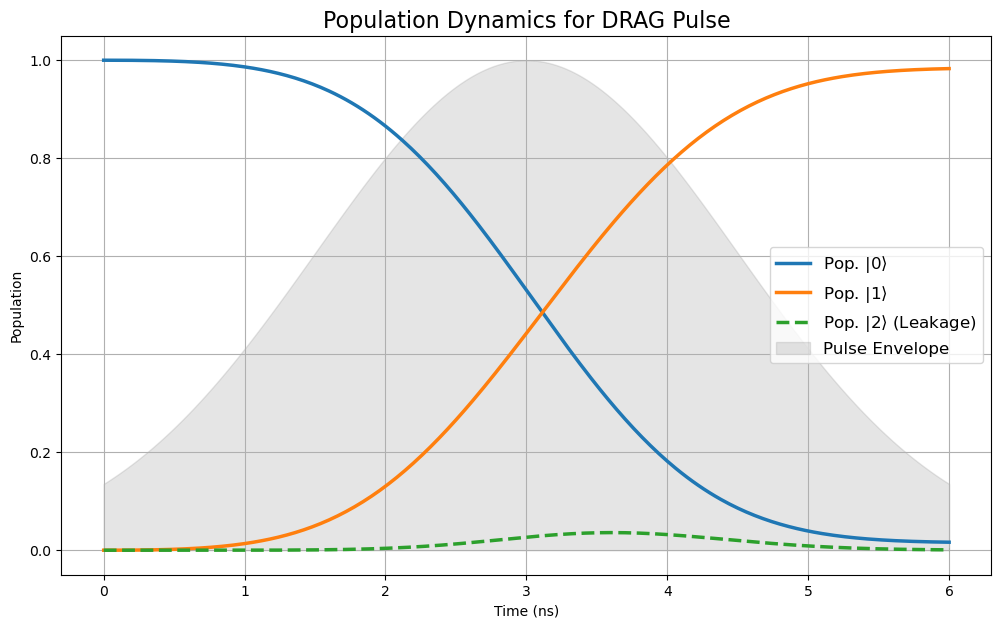

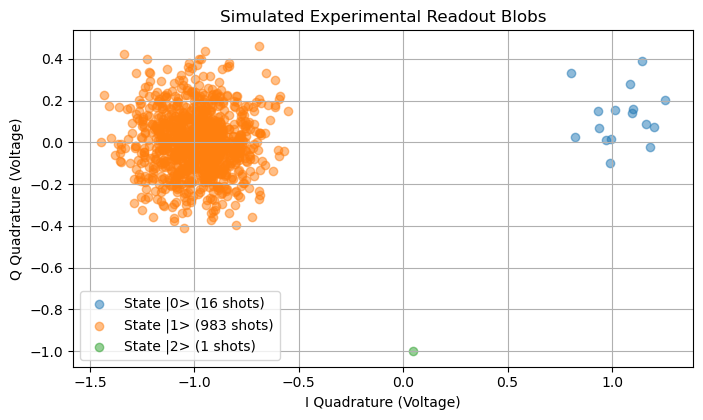


--- Running Simulation for: GRAPE-like Pulse ---
  Gate Time: 6.0 ns
  Final Population Percentages:
    P(|0>): 1.6066%
    P(|1>): 98.3198%
    P(|2>): 0.0735%  <-- Leakage


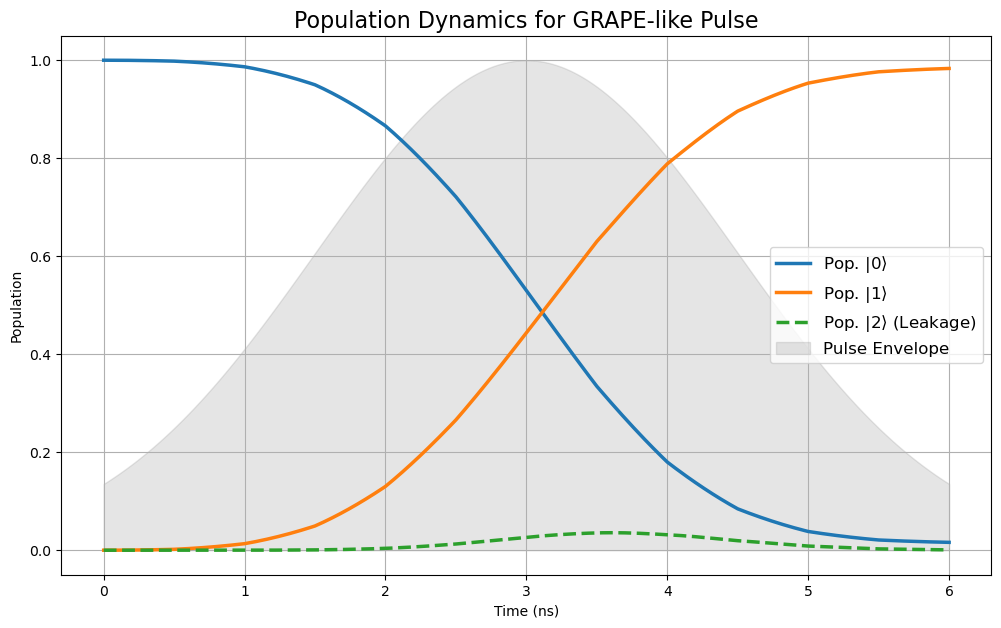

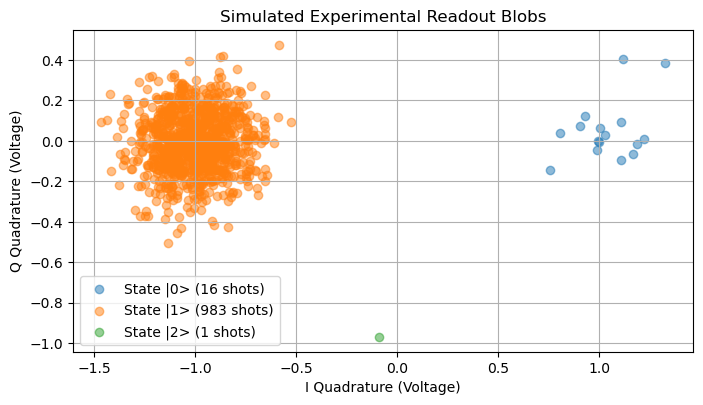

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, destroy, mesolve
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (FROM FIRST PROMPT)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities.
    """
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# HELPER FUNCTION FOR PLOTTING POPULATIONS
# ==============================================================================
def plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm):
    """Generates the population dynamics plot for a given simulation result."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.plot(tlist, pop0, label=r'Pop. $|0\rangle$', lw=2.5)
    ax.plot(tlist, pop1, label=r'Pop. $|1\rangle$', lw=2.5)
    ax.plot(tlist, pop2, label=r'Pop. $|2\rangle$ (Leakage)', lw=2.5, linestyle='--')
    ax.fill_between(tlist, 0, pulse_env_norm, color='gray', alpha=0.2, label='Pulse Envelope')
    ax.set_title(f"Population Dynamics for {label} Pulse", fontsize=16)
    ax.set_xlabel("Time (ns)"), ax.set_ylabel("Population")
    ax.grid(True), ax.legend(fontsize=12), ax.set_ylim(-0.05, 1.05)
    plt.show()


# ==============================================================================
# MAIN SIMULATION FUNCTION
# ==============================================================================
def run_full_comparison_simulation():
    """
    Runs a full comparison of Gaussian, DRAG, and GRAPE-like pulses,
    showing all requested plots and data for each.
    """
    # --- 1. Print the Hamiltonian Being Used ---
    print("="*70)
    print("HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)")
    print("Based on PRL 103, 110501, Eq. (3), with resonant drive (δ₁=0)")
    print("="*70)
    print("H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)")
    print("  - Δ/2π = -0.4 GHz (Anharmonicity)")
    print("  - (a+a†) is the physical X-drive, which includes λ=√2 implicitly.")
    print("  - (σy₀₁) is the effective Y-drive for the DRAG correction.")
    print("="*70 + "\n")

    # --- 2. System and Pulse Parameters ---
    N = 3
    anharmonicity_ghz = -0.4
    anharmonicity_delta = anharmonicity_ghz * 2 * np.pi
    gate_time = 6.0
    pulse_sigma = gate_time / 4.0
    pulse_center = gate_time / 2.0
    tlist = np.linspace(0, gate_time, 301)
    required_area = np.pi
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    # --- 3. Operators and Initial State ---
    a = destroy(N)
    P0, P1, P2 = (basis(N, i) * basis(N, i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j * (basis(N, 0) * basis(N, 1).dag() - basis(N, 1) * basis(N, 0).dag())
    H0 = anharmonicity_delta * P2
    psi0 = basis(N, 0)
    e_ops = [P0, P1, P2]
    
    # --- 3.5. Collapse Operators (Added) ---
    # Typical values for superconducting qubits (T1 ~ 20-100μs, T2 ~ 10-50μs)
    T1 = 20.0  # in microseconds
    T2 = 10.0  # in microseconds
    
    # Convert to nanoseconds (since our simulation is in ns)
    T1_ns = T1 * 1000
    T2_ns = T2 * 1000
    
    # Calculate decay rates
    gamma1 = 1 / T1_ns  # Energy relaxation rate
    gamma_phi = (1 / T2_ns) - (1 / (2 * T1_ns))  # Pure dephasing rate
    
    # Collapse operators
    c_ops = []
    # Energy relaxation |1> -> |0>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Energy relaxation |2> -> |1>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Pure dephasing |0><1| and |1><2|
    c_ops.append(np.sqrt(gamma_phi) * (P0 - P1))
    c_ops.append(np.sqrt(gamma_phi) * (P1 - P2))

    # --- 4. Pulse Envelope Definitions ---
    pulse_args = {'A': pulse_amplitude, 't0': pulse_center, 'sigma': pulse_sigma, 'delta': anharmonicity_delta}
    def gauss_env(t, args): return args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))
    def drag_env(t, args):
        gauss = gauss_env(t, args)
        gauss_derivative = -(t - args['t0']) / (args['sigma']**2) * gauss
        return - (1.0 / args['delta']) * gauss_derivative

    # --- 5. Define All Three Simulations ---
    # Case 1: Standard Gaussian
    H_gauss = [H0, [drive_op_x / 2, gauss_env]]
    # Case 2: Ideal DRAG
    H_drag = [H0, [drive_op_x / 2, gauss_env], [sigma_y01 / 2, drag_env]]
    # Case 3: GRAPE-like (Pixelated DRAG)
    pixel_width = 0.5
    num_pixels = int(gate_time / pixel_width)
    pixel_times = np.linspace(0, gate_time, num_pixels + 1)
    ex_pixels = [gauss_env(t, pulse_args) for t in (pixel_times[:-1] + pixel_width/2)]
    ey_pixels = [drag_env(t, pulse_args) for t in (pixel_times[:-1] + pixel_width/2)]
    def grape_ex_env(t, args):
        if t >= gate_time: return 0.0
        return ex_pixels[int(t / pixel_width)]
    def grape_ey_env(t, args):
        if t >= gate_time: return 0.0
        return ey_pixels[int(t / pixel_width)]
    H_grape = [H0, [drive_op_x / 2, grape_ex_env], [sigma_y01 / 2, grape_ey_env]]

    simulations = [
        {'label': 'Gaussian', 'H': H_gauss, 'args': pulse_args},
        {'label': 'DRAG', 'H': H_drag, 'args': pulse_args},
        {'label': 'GRAPE-like', 'H': H_grape, 'args': {}}, # No args needed for pixelated funcs
    ]

    # --- 6. Run Simulations and Display Results ---
    pulse_envelope_normalized = [gauss_env(t, pulse_args) / pulse_amplitude for t in tlist]

    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Pulse ---")

        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect

        print(f"  Gate Time: {gate_time:.1f} ns")
        print("  Final Population Percentages:")
        print(f"    P(|0>): {pop0[-1]*100:.4f}%")
        print(f"    P(|1>): {pop1[-1]*100:.4f}%")
        print(f"    P(|2>): {pop2[-1]*100:.4f}%  <-- Leakage")

        # Display the plots for this simulation
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_envelope_normalized)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1])


if __name__ == '__main__':
    run_full_comparison_simulation()

HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)
Implementing an X-gate with two sequential π/2-pulses
H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)


--- Running Simulation for: Gaussian Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8962%
    P(|1>): 99.0995%
    P(|2>): 0.0043%  <-- Leakage


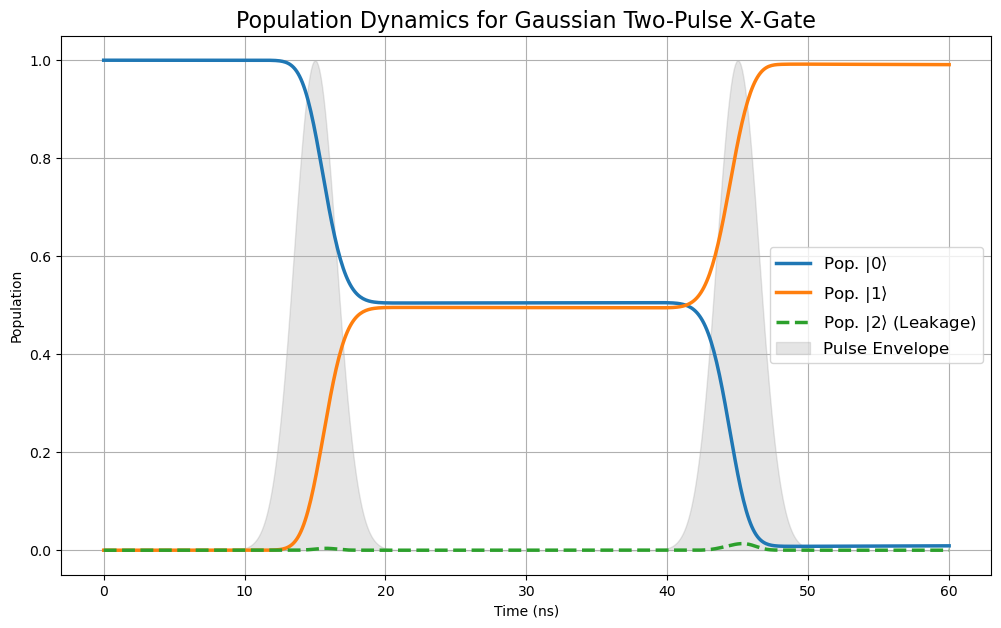

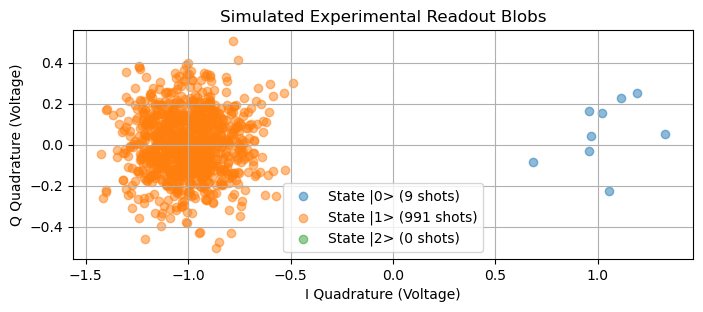


--- Running Simulation for: DRAG Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8506%
    P(|1>): 99.1470%
    P(|2>): 0.0023%  <-- Leakage


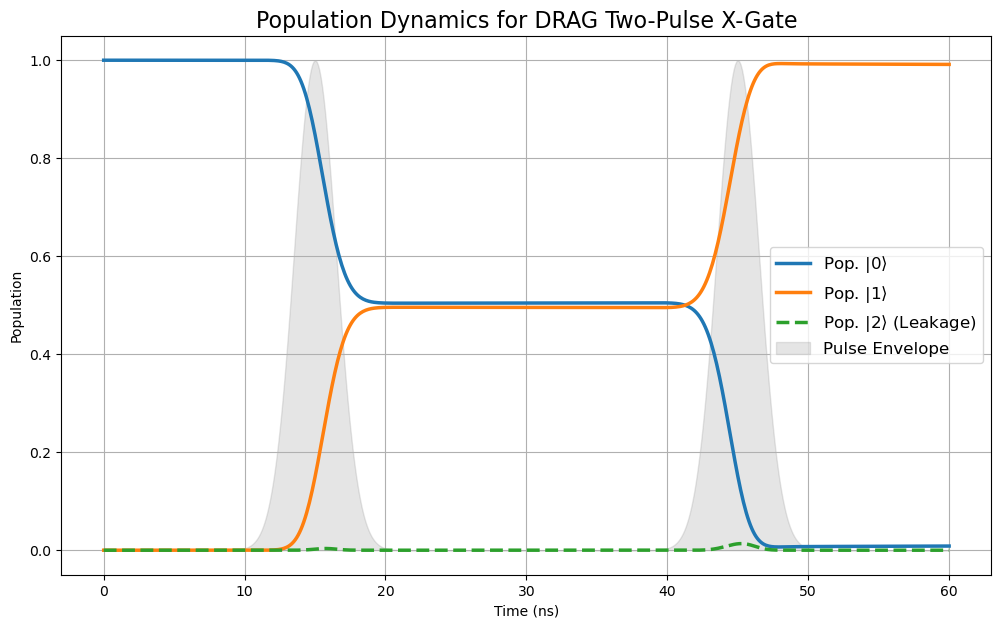

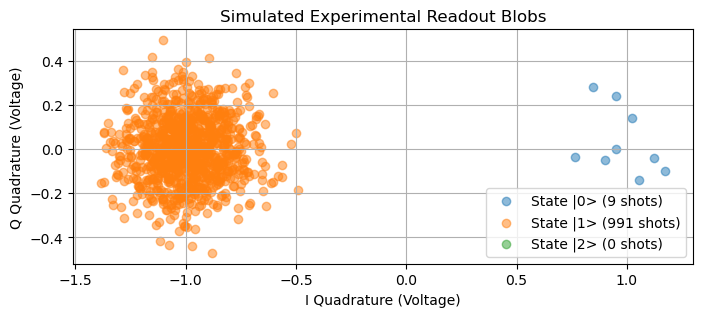


--- Running Simulation for: GRAPE-like Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8623%
    P(|1>): 99.1355%
    P(|2>): 0.0022%  <-- Leakage


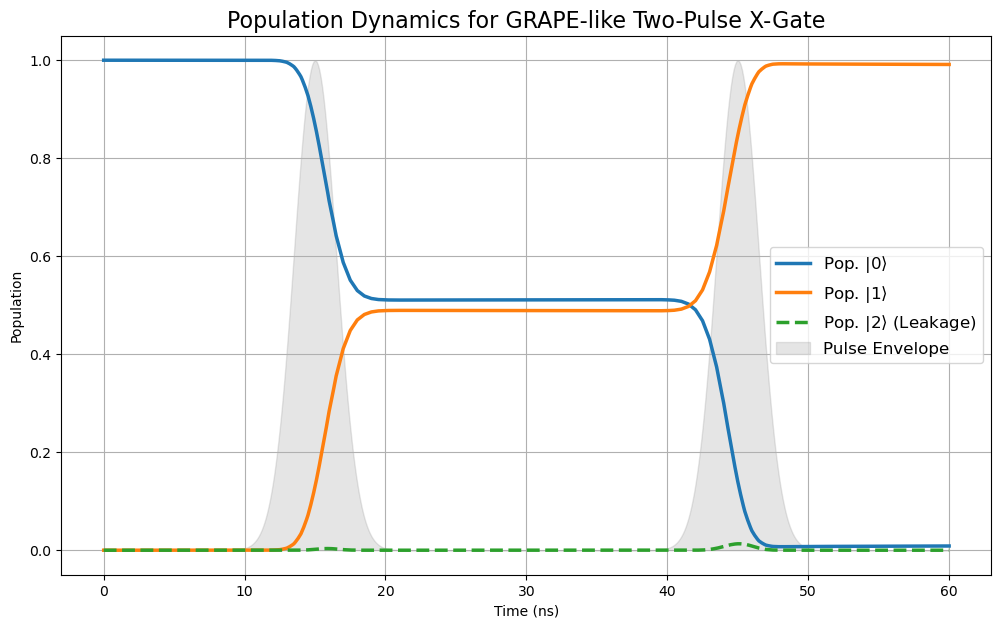

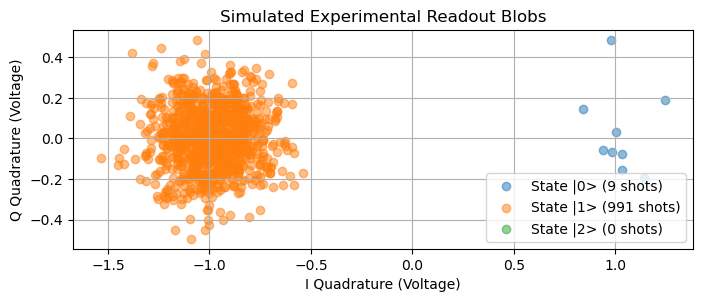

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, destroy, mesolve
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities.
    """
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# HELPER FUNCTION FOR PLOTTING POPULATIONS (UNCHANGED)
# ==============================================================================
def plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.plot(tlist, pop0, label=r'Pop. $|0\rangle$', lw=2.5)
    ax.plot(tlist, pop1, label=r'Pop. $|1\rangle$', lw=2.5)
    ax.plot(tlist, pop2, label=r'Pop. $|2\rangle$ (Leakage)', lw=2.5, linestyle='--')
    ax.fill_between(tlist, 0, pulse_env_norm, color='gray', alpha=0.2, label='Pulse Envelope')
    ax.set_title(f"Population Dynamics for {label} Two-Pulse X-Gate", fontsize=16)
    ax.set_xlabel("Time (ns)"), ax.set_ylabel("Population")
    ax.grid(True), ax.legend(fontsize=12), ax.set_ylim(-0.05, 1.05)
    plt.show()

# ==============================================================================
# MAIN SIMULATION FUNCTION (MODIFIED FOR TWO PULSES)
# ==============================================================================
def run_full_two_pulse_comparison():
    # --- 1. Print the Hamiltonian Being Used ---
    print("="*70)
    print("HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)")
    print("Implementing an X-gate with two sequential π/2-pulses")
    print("="*70)
    print("H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)")
    print("="*70 + "\n")

    # --- 2. System and Pulse Parameters ---
    N = 3
    anharmonicity_ghz = -0.4
    anharmonicity_delta = anharmonicity_ghz * 2 * np.pi
    
    # Timing for two pulses
    total_time = 60.0
    pulse1_t0, pulse2_t0 = 15.0, 45.0
    pulse_duration = 6.0 # Make pulses a bit wider to fit in the time window
    pulse_sigma = pulse_duration / 4.0
    tlist = np.linspace(0, total_time, 601)

    # Area for a single π/2 pulse. Angle = ∫(Amp/2)dt = π/4 => ∫Amp dt = π/2
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    # --- 3. Operators and Initial State ---
    a = destroy(N)
    P0, P1, P2 = (basis(N, i) * basis(N, i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j * (basis(N, 0) * basis(N, 1).dag() - basis(N, 1) * basis(N, 0).dag())
    H0 = anharmonicity_delta * P2
    psi0 = basis(N, 0)
    e_ops = [P0, P1, P2]
    
    # --- 3.5. Collapse Operators (Added) ---
    # Typical values for superconducting qubits (T1 ~ 20-100μs, T2 ~ 10-50μs)
    T1 = 20.0  # in microseconds
    T2 = 10.0  # in microseconds
    
    # Convert to nanoseconds (since our simulation is in ns)
    T1_ns = T1 * 1000
    T2_ns = T2 * 1000
    
    # Calculate decay rates
    gamma1 = 1 / T1_ns  # Energy relaxation rate
    gamma_phi = (1 / T2_ns) - (1 / (2 * T1_ns))  # Pure dephasing rate
    
    # Collapse operators
    c_ops = []
    # Energy relaxation |1> -> |0>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Energy relaxation |2> -> |1>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Pure dephasing |0><1| and |1><2|
    c_ops.append(np.sqrt(gamma_phi) * (P0 - P1))
    c_ops.append(np.sqrt(gamma_phi) * (P1 - P2))

    # --- 4. Two-Pulse Envelope Definitions ---
    pulse_args = {
        'A': pulse_amplitude, 't0_1': pulse1_t0, 't0_2': pulse2_t0,
        'sigma': pulse_sigma, 'delta': anharmonicity_delta
    }
    
    def two_pulse_gauss_env(t, args):
        p1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        p2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        return p1 + p2

    def two_pulse_drag_env(t, args):
        gauss1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        deriv1 = -(t - args['t0_1']) / (args['sigma']**2) * gauss1
        
        gauss2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        deriv2 = -(t - args['t0_2']) / (args['sigma']**2) * gauss2
        
        return -(1.0 / args['delta']) * (deriv1 + deriv2)

    # --- 5. Define All Three Simulations ---
    # Case 1: Standard Gaussian
    H_gauss = [H0, [drive_op_x / 2, two_pulse_gauss_env]]
    # Case 2: Ideal DRAG
    H_drag = [H0, [drive_op_x / 2, two_pulse_gauss_env], [sigma_y01 / 2, two_pulse_drag_env]]
    # Case 3: GRAPE-like (Pixelated DRAG)
    pixel_width = 0.5
    num_pixels = int(total_time / pixel_width)
    ex_pixels = [two_pulse_gauss_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    ey_pixels = [two_pulse_drag_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    def grape_ex_env(t, args):
        if t >= total_time: return 0.0
        return ex_pixels[int(t / pixel_width)]
    def grape_ey_env(t, args):
        if t >= total_time: return 0.0
        return ey_pixels[int(t / pixel_width)]
    H_grape = [H0, [drive_op_x / 2, grape_ex_env], [sigma_y01 / 2, grape_ey_env]]

    simulations = [
        {'label': 'Gaussian', 'H': H_gauss, 'args': pulse_args},
        {'label': 'DRAG', 'H': H_drag, 'args': pulse_args},
        {'label': 'GRAPE-like', 'H': H_grape, 'args': {}},
    ]

    # --- 6. Run Simulations and Display Results ---
    pulse_envelope_normalized = [two_pulse_gauss_env(t, pulse_args) / pulse_amplitude for t in tlist]

    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Two-Pulse X-Gate ---")

        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect

        print(f"  Total Gate Time: {total_time:.1f} ns")
        print("  Final Population Percentages:")
        print(f"    P(|0>): {pop0[-1]*100:.4f}%")
        print(f"    P(|1>): {pop1[-1]*100:.4f}%")
        print(f"    P(|2>): {pop2[-1]*100:.4f}%  <-- Leakage")

        # Display the plots for this simulation
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_envelope_normalized)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1])


if __name__ == '__main__':
    run_full_two_pulse_comparison()

HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)
Implementing an X-gate with three sequential pulses
H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)


--- Running Simulation for: Gaussian Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9236%
    P(|1>): 99.0738%
    P(|2>): 0.0026%  <-- Leakage


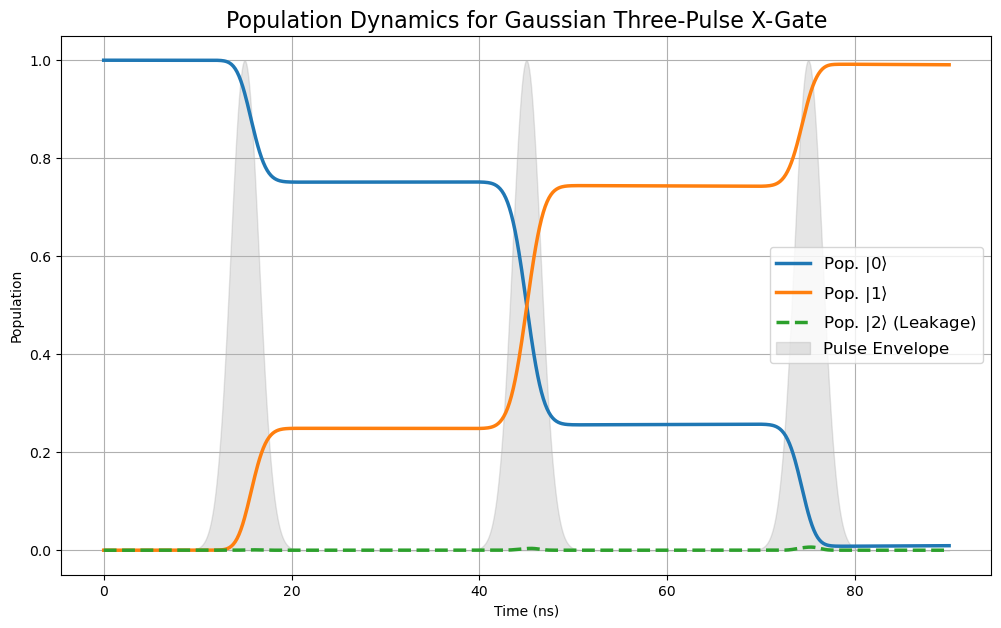

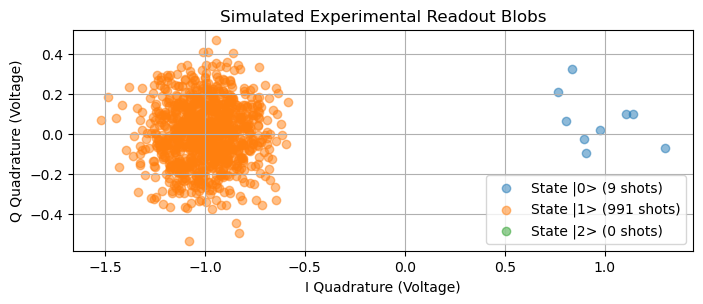


--- Running Simulation for: DRAG Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9013%
    P(|1>): 99.0971%
    P(|2>): 0.0016%  <-- Leakage


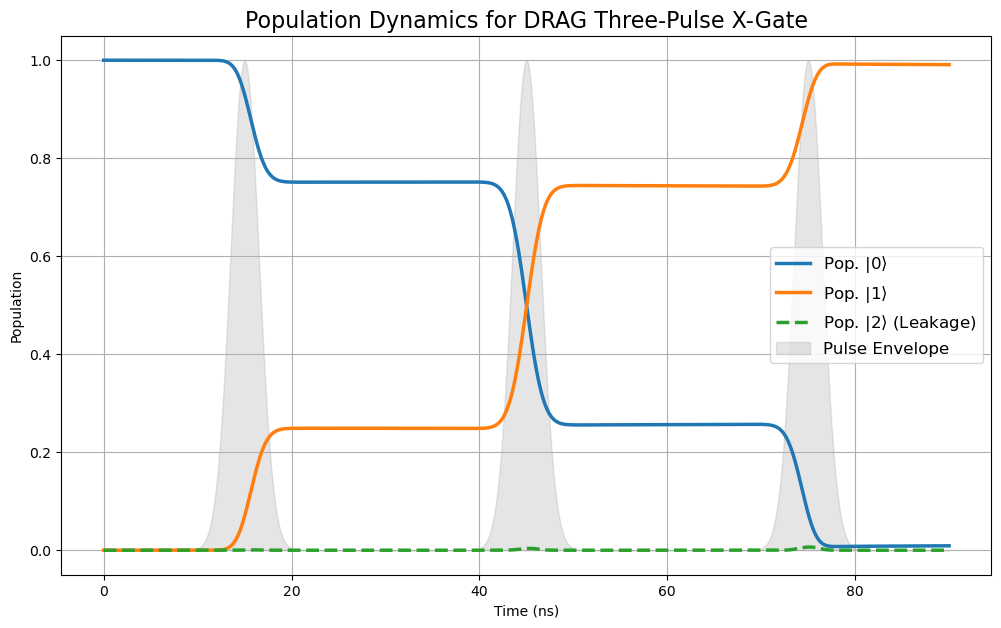

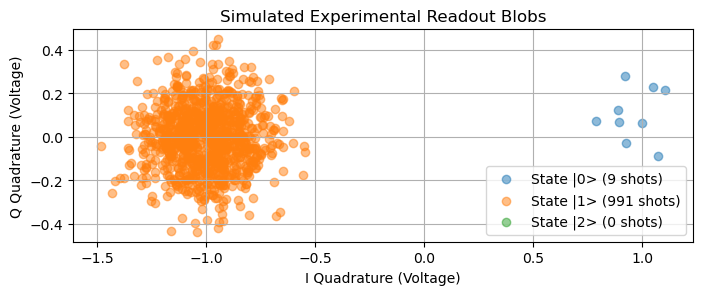


--- Running Simulation for: GRAPE-like Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9087%
    P(|1>): 99.0899%
    P(|2>): 0.0014%  <-- Leakage


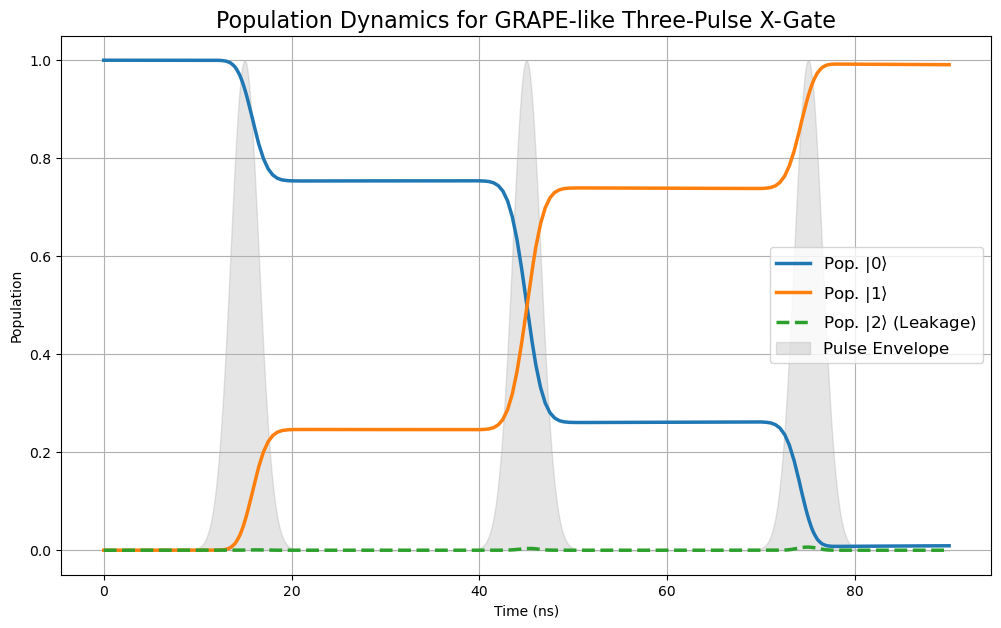

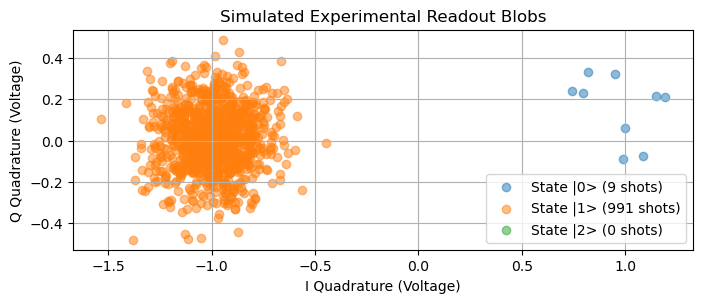

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, destroy, mesolve
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities.
    """
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# HELPER FUNCTION FOR PLOTTING POPULATIONS (UNCHANGED)
# ==============================================================================
def plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.plot(tlist, pop0, label=r'Pop. $|0\rangle$', lw=2.5)
    ax.plot(tlist, pop1, label=r'Pop. $|1\rangle$', lw=2.5)
    ax.plot(tlist, pop2, label=r'Pop. $|2\rangle$ (Leakage)', lw=2.5, linestyle='--')
    ax.fill_between(tlist, 0, pulse_env_norm, color='gray', alpha=0.2, label='Pulse Envelope')
    ax.set_title(f"Population Dynamics for {label} Three-Pulse X-Gate", fontsize=16)
    ax.set_xlabel("Time (ns)"), ax.set_ylabel("Population")
    ax.grid(True), ax.legend(fontsize=12), ax.set_ylim(-0.05, 1.05)
    plt.show()

# ==============================================================================
# MAIN SIMULATION FUNCTION (MODIFIED FOR THREE PULSES)
# ==============================================================================
def run_full_three_pulse_comparison():
    # --- 1. Print the Hamiltonian Being Used ---
    print("="*70)
    print("HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)")
    print("Implementing an X-gate with three sequential pulses")
    print("="*70)
    print("H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)")
    print("="*70 + "\n")

    # --- 2. System and Pulse Parameters ---
    N = 3
    anharmonicity_ghz = -0.4
    anharmonicity_delta = anharmonicity_ghz * 2 * np.pi
    
    # Timing for three pulses (π/3, π/3, π/3)
    total_time = 90.0
    pulse1_t0, pulse2_t0, pulse3_t0 = 15.0, 45.0, 75.0
    pulse_duration = 6.0
    pulse_sigma = pulse_duration / 4.0
    tlist = np.linspace(0, total_time, 901)

    # Area for each π/3 pulse (total rotation = π)
    required_area = np.pi / 3.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    # --- 3. Operators and Initial State ---
    a = destroy(N)
    P0, P1, P2 = (basis(N, i) * basis(N, i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j * (basis(N, 0) * basis(N, 1).dag() - basis(N, 1) * basis(N, 0).dag())
    H0 = anharmonicity_delta * P2
    psi0 = basis(N, 0)
    e_ops = [P0, P1, P2]
    
    # --- 3.5. Collapse Operators ---
    # Typical values for superconducting qubits (T1 ~ 20-100μs, T2 ~ 10-50μs)
    T1 = 20.0  # in microseconds
    T2 = 10.0  # in microseconds
    
    # Convert to nanoseconds (since our simulation is in ns)
    T1_ns = T1 * 1000
    T2_ns = T2 * 1000
    
    # Calculate decay rates
    gamma1 = 1 / T1_ns  # Energy relaxation rate
    gamma_phi = (1 / T2_ns) - (1 / (2 * T1_ns))  # Pure dephasing rate
    
    # Collapse operators
    c_ops = []
    # Energy relaxation |1> -> |0>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Energy relaxation |2> -> |1>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Pure dephasing |0><1| and |1><2|
    c_ops.append(np.sqrt(gamma_phi) * (P0 - P1))
    c_ops.append(np.sqrt(gamma_phi) * (P1 - P2))

    # --- 4. Three-Pulse Envelope Definitions ---
    pulse_args = {
        'A': pulse_amplitude, 
        't0_1': pulse1_t0, 't0_2': pulse2_t0, 't0_3': pulse3_t0,
        'sigma': pulse_sigma, 'delta': anharmonicity_delta
    }
    
    def three_pulse_gauss_env(t, args):
        p1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        p2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        p3 = args['A'] * np.exp(-(t - args['t0_3'])**2 / (2 * args['sigma']**2))
        return p1 + p2 + p3

    def three_pulse_drag_env(t, args):
        gauss1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        deriv1 = -(t - args['t0_1']) / (args['sigma']**2) * gauss1
        
        gauss2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        deriv2 = -(t - args['t0_2']) / (args['sigma']**2) * gauss2
        
        gauss3 = args['A'] * np.exp(-(t - args['t0_3'])**2 / (2 * args['sigma']**2))
        deriv3 = -(t - args['t0_3']) / (args['sigma']**2) * gauss3
        
        return -(1.0 / args['delta']) * (deriv1 + deriv2 + deriv3)

    # --- 5. Define All Three Simulations ---
    # Case 1: Standard Gaussian
    H_gauss = [H0, [drive_op_x / 2, three_pulse_gauss_env]]
    # Case 2: Ideal DRAG
    H_drag = [H0, [drive_op_x / 2, three_pulse_gauss_env], [sigma_y01 / 2, three_pulse_drag_env]]
    # Case 3: GRAPE-like (Pixelated DRAG)
    pixel_width = 0.5
    num_pixels = int(total_time / pixel_width)
    ex_pixels = [three_pulse_gauss_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    ey_pixels = [three_pulse_drag_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    def grape_ex_env(t, args):
        if t >= total_time: return 0.0
        return ex_pixels[int(t / pixel_width)]
    def grape_ey_env(t, args):
        if t >= total_time: return 0.0
        return ey_pixels[int(t / pixel_width)]
    H_grape = [H0, [drive_op_x / 2, grape_ex_env], [sigma_y01 / 2, grape_ey_env]]

    simulations = [
        {'label': 'Gaussian', 'H': H_gauss, 'args': pulse_args},
        {'label': 'DRAG', 'H': H_drag, 'args': pulse_args},
        {'label': 'GRAPE-like', 'H': H_grape, 'args': {}},
    ]

    # --- 6. Run Simulations and Display Results ---
    pulse_envelope_normalized = [three_pulse_gauss_env(t, pulse_args) / pulse_amplitude for t in tlist]

    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Three-Pulse X-Gate ---")
        print("Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)")

        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect

        print(f"  Total Gate Time: {total_time:.1f} ns")
        print("  Final Population Percentages:")
        print(f"    P(|0>): {pop0[-1]*100:.4f}%")
        print(f"    P(|1>): {pop1[-1]*100:.4f}%")
        print(f"    P(|2>): {pop2[-1]*100:.4f}%  <-- Leakage")

        # Display the plots for this simulation
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_envelope_normalized)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1])


if __name__ == '__main__':
    run_full_three_pulse_comparison()